# 1

In [ ]:
# ============================================================================
# FIX: CONVERT ALL LABELS TO USDA CODES
# ============================================================================

print("\n" + "="*60)
print("FIX: CONVERTING ALL LABELS TO USDA CODES")
print("="*60)

# Path to your combined dataset
COMBINED_PATH = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\combined"

# Load the current mixed data
X_combined = np.load(os.path.join(COMBINED_PATH, "X_combined.npy"))
y_combined_mixed = np.load(os.path.join(COMBINED_PATH, "y_combined.npy"))

print(f" Loaded X_combined shape: {X_combined.shape}")
print(f" Loaded y_combined (mixed) shape: {y_combined_mixed.shape}")
print(f"   Unique values before conversion: {np.unique(y_combined_mixed)}")

# Create mapping from 1-5 labels to USDA codes
label_to_usda = {
    1: 36,   # Alfalfa
    2: 57,   # Rice
    3: 69,   # Grapes
    4: 74,   # Pistachios
    5: 204   # Almonds
}

# Convert all labels to USDA codes
y_combined_fixed = y_combined_mixed.copy()

# Convert labels 1-5 to USDA codes
for label_1_5, usda_code in label_to_usda.items():
    y_combined_fixed[y_combined_mixed == label_1_5] = usda_code

print(f"\n After conversion:")
print(f"   Unique values: {np.unique(y_combined_fixed)}")

# Verify the distribution matches expected totals
print(f"\n FINAL DISTRIBUTION (USDA codes):")
print(f"{'Crop':<15} {'USDA Code':<10} {'Count':<12} {'Source':<20}")
print("-" * 60)

# Expected totals from your extraction
expected_totals = {
    36: 306 + 32066,   # Old Alfalfa (306) + New Alfalfa (32,066)
    57: 98 + 14,       # Old Rice (98) + New Rice (14)
    69: 4285 + 87334,  # Old Grapes (4,285) + New Grapes (87,334)
    74: 5 + 441,       # Old Pistachios (5) + New Pistachios (441)
    204: 1844 + 85     # Old Almonds (1,844) + New Almonds (85)
}

crop_names = {36: "Alfalfa", 57: "Rice", 69: "Grapes", 74: "Pistachios", 204: "Almonds"}

for code in [36, 57, 69, 74, 204]:
    actual_count = np.sum(y_combined_fixed == code)
    expected = expected_totals[code]
    status = "✅" if actual_count == expected else "❌"
    print(f"{crop_names[code]:<15} {code:<10} {actual_count:<12,} {expected:,} ({status})")

print("-" * 60)
print(f"{'TOTAL':<15} {'':<10} {len(y_combined_fixed):<12,} {sum(expected_totals.values()):,}")

# Save the fixed version (overwrite or save as new file)
np.save(os.path.join(COMBINED_PATH, "X_combined.npy"), X_combined)
np.save(os.path.join(COMBINED_PATH, "y_combined.npy"), y_combined_fixed)

print(f"\n Fixed combined dataset saved!")
print(f"   Location: {COMBINED_PATH}")
print(f"   Files: X_combined.npy, y_combined.npy (overwritten with USDA codes)")

# Also save a backup just in case
np.save(os.path.join(COMBINED_PATH, "y_combined_backup.npy"), y_combined_mixed)
print(f"   Backup of original saved as: y_combined_backup.npy")


FIX: CONVERTING ALL LABELS TO USDA CODES
✅ Loaded X_combined shape: (126478, 36, 10)
✅ Loaded y_combined (mixed) shape: (126478,)
   Unique values before conversion: [ 36  57  69  74 204]

✅ After conversion:
   Unique values: [ 36  57  69  74 204]

📊 FINAL DISTRIBUTION (USDA codes):
Crop            USDA Code  Count        Source              
------------------------------------------------------------
Alfalfa         36         32,372       32,372 (✅)
Rice            57         112          112 (✅)
Grapes          69         91,619       91,619 (✅)
Pistachios      74         446          446 (✅)
Almonds         204        1,929        1,929 (✅)
------------------------------------------------------------
TOTAL                      126,478      126,478

✅ Fixed combined dataset saved!
   Location: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\combined
   Files: X_combined.npy, y_combined.npy (overwritten with USDA codes)
   Backup of original s

In [38]:
# ============================================================================
# NOTEBOOK 2b: EXPLORATORY DATA ANALYSIS - FIXED COMBINED DATASET (BALANCED)
# ============================================================================
# Purpose: Perform EDA on the fixed combined dataset
# - 126,478 samples total (6,538 old + 119,940 new)
# - 5 crop types with USDA codes (36,57,69,74,204)
# - 36 time steps × 10 spectral bands
# - BALANCED sampling: max 4000 samples per crop for visualization
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.utils import resample
import os
import warnings
warnings.filterwarnings('ignore')

# Create output directory
os.makedirs("outputs/figures", exist_ok=True)

print("="*60)
print("NOTEBOOK 2b: EDA - FIXED COMBINED DATASET (BALANCED)")
print("="*60)

NOTEBOOK 2b: EDA - FIXED COMBINED DATASET (BALANCED)


# 2: Load Fixed Combined Dataset

In [39]:
# ============================================================================
# STEP 1: LOAD FIXED COMBINED DATASET
# ============================================================================

print("\n" + "="*60)
print("STEP 1: LOADING FIXED COMBINED DATASET")
print("="*60)

# Path to combined dataset
COMBINED_PATH = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\combined"

X = np.load(os.path.join(COMBINED_PATH, "X_combined.npy"))
y = np.load(os.path.join(COMBINED_PATH, "y_combined.npy"))

print(f"✅ X shape: {X.shape} (samples, time_steps, bands)")
print(f"✅ y shape: {y.shape}")
print(f"✅ Total samples: {len(y):,}")
print(f"✅ Time steps: {X.shape[1]}")
print(f"✅ Spectral bands: {X.shape[2]}")
print(f"✅ Unique labels (USDA codes): {np.unique(y)}")


STEP 1: LOADING FIXED COMBINED DATASET
✅ X shape: (126478, 36, 10) (samples, time_steps, bands)
✅ y shape: (126478,)
✅ Total samples: 126,478
✅ Time steps: 36
✅ Spectral bands: 10
✅ Unique labels (USDA codes): [ 36  57  69  74 204]


# 3: Class Distribution (Full Dataset)


STEP 2: CLASS DISTRIBUTION (FULL DATASET)

Class Distribution (Full Dataset):
Crop Name            Code     Count        Percentage  
------------------------------------------------------------
Alfalfa              36       32,372       25.6        %
Rice                 57       112          0.1         %
Grapes               69       91,619       72.4        %
Pistachios           74       446          0.4         %
Almonds              204      1,929        1.5         %
------------------------------------------------------------
TOTAL                         126,478      100.0       %


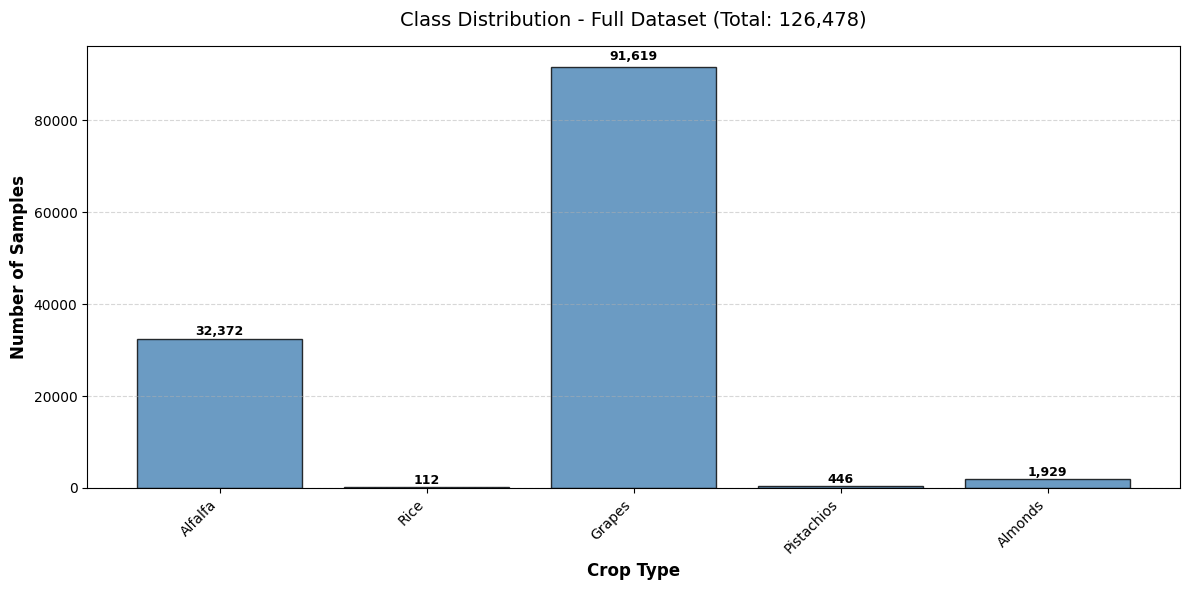


✅ Saved: outputs/figures/combined_full_distribution.png


In [40]:
# ============================================================================
# STEP 2: CLASS DISTRIBUTION (FULL DATASET)
# ============================================================================

print("\n" + "="*60)
print("STEP 2: CLASS DISTRIBUTION (FULL DATASET)")
print("="*60)

# CORRECT mapping for combined dataset (USDA codes)
CROP_NAMES = {
    36: "Alfalfa",
    57: "Rice",
    69: "Grapes",
    74: "Pistachios",
    204: "Almonds"
}

# Get unique crops from data
unique, counts = np.unique(y, return_counts=True)

print("\nClass Distribution (Full Dataset):")
print(f"{'Crop Name':<20} {'Code':<8} {'Count':<12} {'Percentage':<12}")
print("-" * 60)

# Print named crops
named_crops = [36, 57, 69, 74, 204]
for code in named_crops:
    if code in unique:
        idx = list(unique).index(code)
        count = counts[idx]
        name = CROP_NAMES.get(code, f"Unknown({code})")
        print(f"{name:<20} {code:<8} {count:<12,} {100*count/len(y):<12.1f}%")

print("-" * 60)
print(f"{'TOTAL':<20} {'':<8} {len(y):<12,} {100.0:<12.1f}%")

# Bar chart - Full dataset
plt.figure(figsize=(12, 6))

labels = []
bar_counts = []

for code in named_crops:
    if code in unique:
        labels.append(CROP_NAMES.get(code, f"Code {code}"))
        bar_counts.append(counts[list(unique).index(code)])

bars = plt.bar(range(len(labels)), bar_counts, color='steelblue', edgecolor='black', alpha=0.8)

plt.xticks(range(len(labels)), labels, rotation=45, ha='right', fontsize=10)
plt.xlabel("Crop Type", fontsize=12, fontweight='bold')
plt.ylabel("Number of Samples", fontsize=12, fontweight='bold')
plt.title(f"Class Distribution - Full Dataset (Total: {len(y):,})", fontsize=14, pad=15)

for bar, count in zip(bars, bar_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(10, count*0.01),
             f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/figures/combined_full_distribution.png", dpi=300)
plt.show()

print("\n✅ Saved: outputs/figures/combined_full_distribution.png")

# 4: Balanced Sampling (Max 4000 per crop)

In [41]:
# ============================================================================
# STEP 3: BALANCED SAMPLING (Max 4000 samples per crop)
# ============================================================================

print("\n" + "="*60)
print("STEP 3: BALANCED SAMPLING (Max 4000 samples per crop)")
print("="*60)

MAX_SAMPLES_PER_CROP = 4000

# Create balanced dataset for visualization
X_balanced_list = []
y_balanced_list = []
samples_used = {}

for code in named_crops:
    indices = np.where(y == code)[0]
    total_available = len(indices)
    n_samples = min(MAX_SAMPLES_PER_CROP, total_available)
    samples_used[code] = n_samples
    
    # Randomly select samples
    np.random.seed(42)  # For reproducibility
    selected_indices = np.random.choice(indices, n_samples, replace=False)
    
    X_balanced_list.append(X[selected_indices])
    y_balanced_list.append(y[selected_indices])
    
    name = CROP_NAMES.get(code, f"Code {code}")
    print(f"  {name:<20}: {n_samples:,} samples (total available: {total_available:,})")

X_balanced = np.vstack(X_balanced_list)
y_balanced = np.concatenate(y_balanced_list)

print(f"\n✅ Balanced dataset created:")
print(f"   X_balanced shape: {X_balanced.shape}")
print(f"   y_balanced shape: {y_balanced.shape}")
print(f"   Total balanced samples: {len(y_balanced):,}")


STEP 3: BALANCED SAMPLING (Max 4000 samples per crop)
  Alfalfa             : 4,000 samples (total available: 32,372)
  Rice                : 112 samples (total available: 112)
  Grapes              : 4,000 samples (total available: 91,619)
  Pistachios          : 446 samples (total available: 446)
  Almonds             : 1,929 samples (total available: 1,929)

✅ Balanced dataset created:
   X_balanced shape: (10487, 36, 10)
   y_balanced shape: (10487,)
   Total balanced samples: 10,487


# 5: Class Distribution (Balanced Dataset)


STEP 4: CLASS DISTRIBUTION (Balanced Dataset)

Class Distribution (Balanced Dataset - Max 4000 per crop):
Crop Name            Code     Count        Percentage  
------------------------------------------------------------
Alfalfa              36       4,000        38.1        %
Rice                 57       112          1.1         %
Grapes               69       4,000        38.1        %
Pistachios           74       446          4.3         %
Almonds              204      1,929        18.4        %
------------------------------------------------------------
TOTAL                         10,487       100.0       %


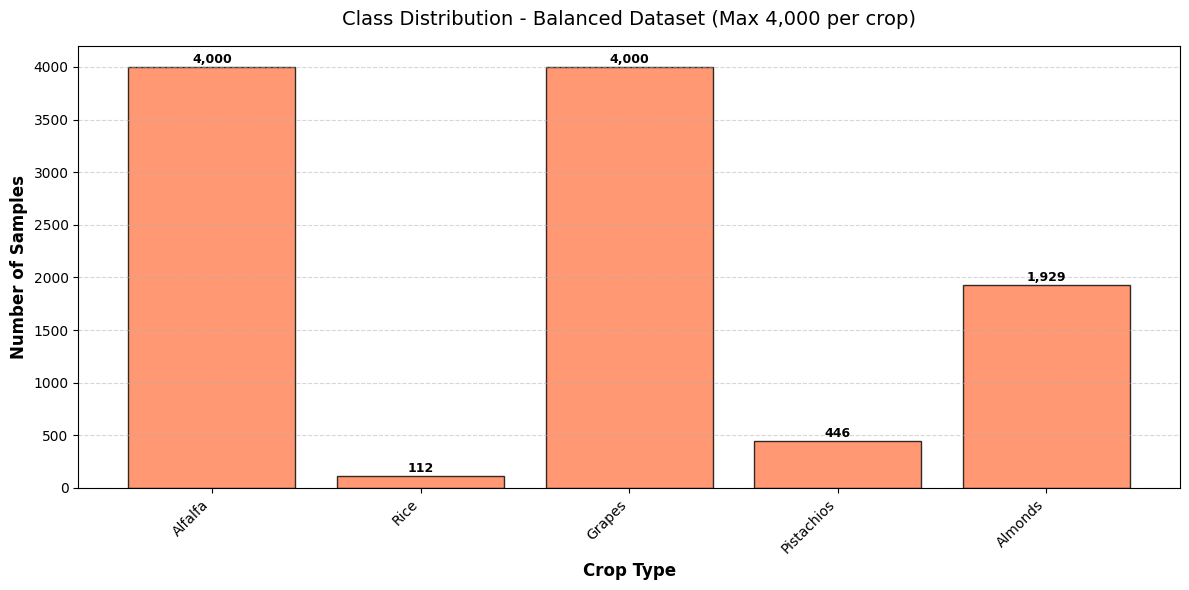


✅ Saved: outputs/figures/combined_balanced_distribution.png


In [42]:
# ============================================================================
# STEP 4: CLASS DISTRIBUTION (Balanced Dataset)
# ============================================================================

print("\n" + "="*60)
print("STEP 4: CLASS DISTRIBUTION (Balanced Dataset)")
print("="*60)

unique_bal, counts_bal = np.unique(y_balanced, return_counts=True)

print("\nClass Distribution (Balanced Dataset - Max 4000 per crop):")
print(f"{'Crop Name':<20} {'Code':<8} {'Count':<12} {'Percentage':<12}")
print("-" * 60)

for code in named_crops:
    if code in unique_bal:
        idx = list(unique_bal).index(code)
        count = counts_bal[idx]
        name = CROP_NAMES.get(code, f"Unknown({code})")
        print(f"{name:<20} {code:<8} {count:<12,} {100*count/len(y_balanced):<12.1f}%")

print("-" * 60)
print(f"{'TOTAL':<20} {'':<8} {len(y_balanced):<12,} {100.0:<12.1f}%")

# Bar chart - Balanced dataset
plt.figure(figsize=(12, 6))

labels_bal = []
bar_counts_bal = []

for code in named_crops:
    if code in unique_bal:
        labels_bal.append(CROP_NAMES.get(code, f"Code {code}"))
        bar_counts_bal.append(counts_bal[list(unique_bal).index(code)])

bars_bal = plt.bar(range(len(labels_bal)), bar_counts_bal, color='coral', edgecolor='black', alpha=0.8)

plt.xticks(range(len(labels_bal)), labels_bal, rotation=45, ha='right', fontsize=10)
plt.xlabel("Crop Type", fontsize=12, fontweight='bold')
plt.ylabel("Number of Samples", fontsize=12, fontweight='bold')
plt.title(f"Class Distribution - Balanced Dataset (Max {MAX_SAMPLES_PER_CROP:,} per crop)", 
          fontsize=14, pad=15)

for bar, count in zip(bars_bal, bar_counts_bal):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/figures/combined_balanced_distribution.png", dpi=300)
plt.show()

print("\n✅ Saved: outputs/figures/combined_balanced_distribution.png")

# 6: NDVI Time-Series Profiles (Balanced - Like Article Figure 2)


STEP 5: NDVI TIME-SERIES PROFILES (Balanced)
  Alfalfa             : 4000 samples used for NDVI curves
  Rice                : 112 samples used for NDVI curves
  Grapes              : 4000 samples used for NDVI curves
  Pistachios          : 446 samples used for NDVI curves
  Almonds             : 1929 samples used for NDVI curves


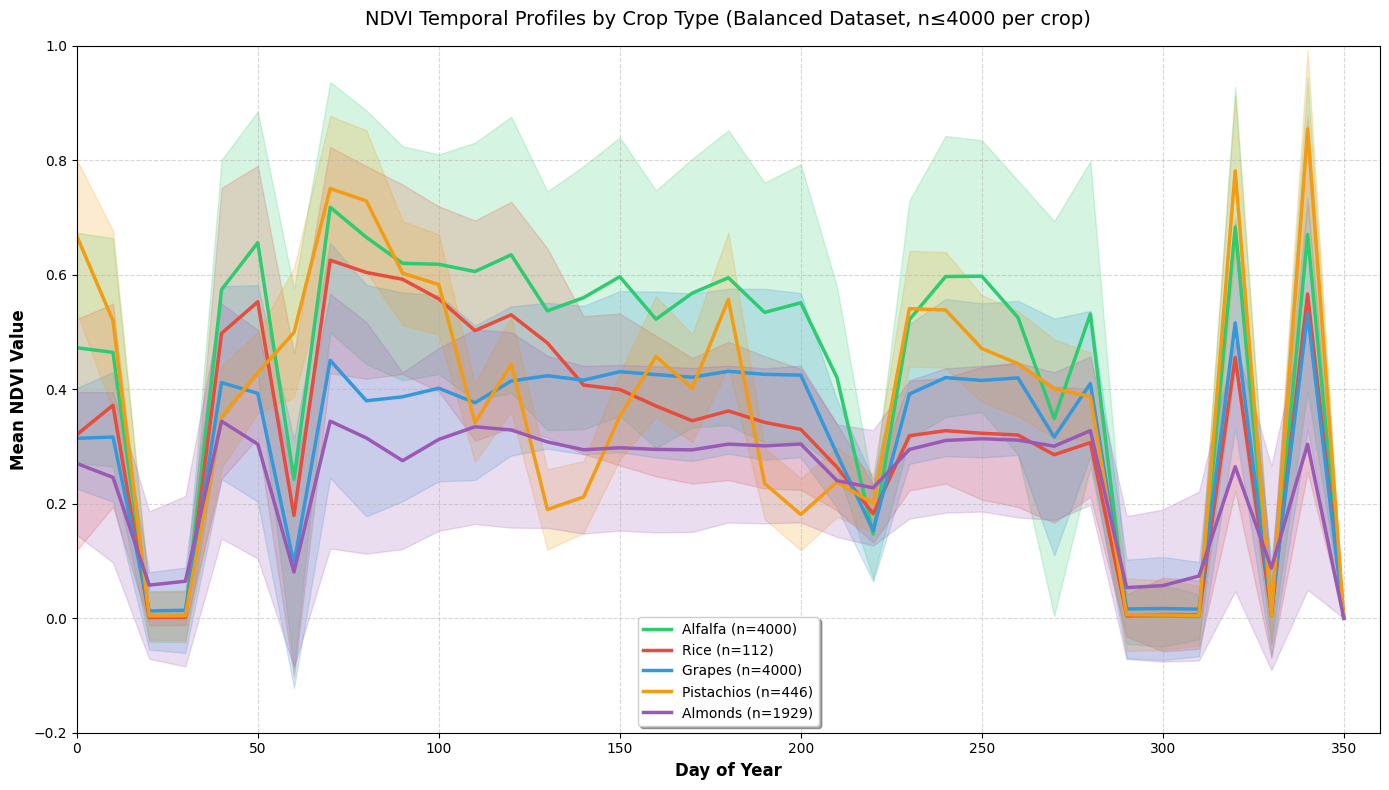


✅ Saved: outputs/figures/balanced_ndvi_profiles.png


In [43]:
# ============================================================================
# STEP 5: NDVI TIME-SERIES PROFILES (BALANCED - Like Article Figure 2)
# ============================================================================

print("\n" + "="*60)
print("STEP 5: NDVI TIME-SERIES PROFILES (Balanced)")
print("="*60)

def calculate_ndvi(pixel_data, red_band_idx=2, nir_band_idx=6):
    """Calculate NDVI for a pixel time series."""
    epsilon = 1e-10
    red = pixel_data[:, red_band_idx]
    nir = pixel_data[:, nir_band_idx]
    numerator = nir - red
    denominator = nir + red + epsilon
    ndvi = numerator / denominator
    return np.nan_to_num(ndvi, nan=0.0, posinf=0.0, neginf=0.0)

# Group samples by crop code from balanced dataset
crop_ndvi = {}

for crop_code in named_crops:
    indices = np.where(y_balanced == crop_code)[0]
    
    # Use all balanced samples (already capped at 4000)
    ndvi_list = []
    for idx in indices:
        ndvi = calculate_ndvi(X_balanced[idx])
        ndvi_list.append(ndvi)
    
    crop_ndvi[crop_code] = ndvi_list
    name = CROP_NAMES.get(crop_code, f"Code {crop_code}")
    print(f"  {name:<20}: {len(ndvi_list)} samples used for NDVI curves")

time_steps = np.arange(36) * 10  # 10-day intervals

# Plot all crops on same graph (like article Figure 2)
plt.figure(figsize=(14, 8))

colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
for idx, (crop_code, ndvi_list) in enumerate(crop_ndvi.items()):
    mean_ndvi = np.mean(ndvi_list, axis=0)
    std_ndvi = np.std(ndvi_list, axis=0)
    name = CROP_NAMES.get(crop_code, f"Code {crop_code}")
    n_samples = samples_used[crop_code]
    
    plt.plot(time_steps, mean_ndvi, linewidth=2.5, color=colors[idx],
             label=f"{name} (n={n_samples})")
    plt.fill_between(time_steps, mean_ndvi - std_ndvi, mean_ndvi + std_ndvi,
                     alpha=0.2, color=colors[idx])

plt.xlabel("Day of Year", fontsize=12, fontweight='bold')
plt.ylabel("Mean NDVI Value", fontsize=12, fontweight='bold')
plt.title("NDVI Temporal Profiles by Crop Type (Balanced Dataset, n≤4000 per crop)", 
          fontsize=14, pad=15)
plt.ylim(-0.2, 1.0)
plt.xlim(0, 360)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', fontsize=10, shadow=True)
plt.tight_layout()
plt.savefig("outputs/figures/balanced_ndvi_profiles.png", dpi=300)
plt.show()

print("\n✅ Saved: outputs/figures/balanced_ndvi_profiles.png")

# 7: Temporal Patterns - Separate Subplots (Balanced)


STEP 6: TEMPORAL PATTERNS - Separate Subplots (Balanced)


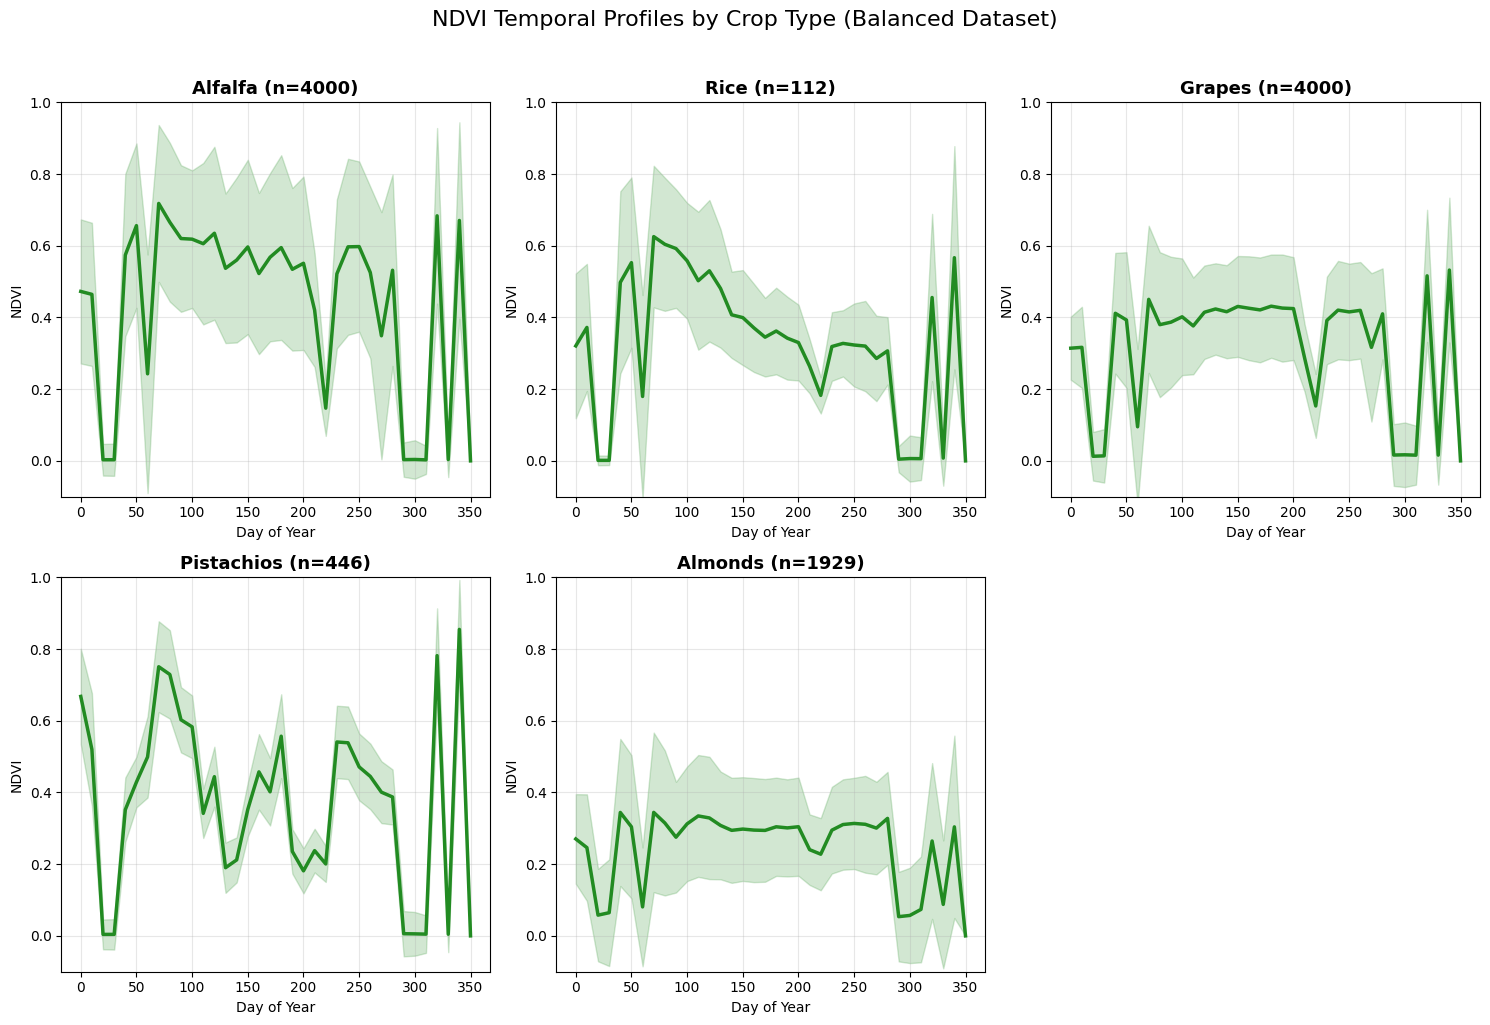


✅ Saved: outputs/figures/balanced_ndvi_subplots.png


In [44]:
# ============================================================================
# STEP 6: TEMPORAL PATTERNS - Separate Subplots (Balanced)
# ============================================================================

print("\n" + "="*60)
print("STEP 6: TEMPORAL PATTERNS - Separate Subplots (Balanced)")
print("="*60)

n_crops = len(crop_ndvi)
n_cols = min(3, n_crops)
n_rows = (n_crops + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_crops > 1 else [axes]

for idx, (crop_code, ndvi_list) in enumerate(crop_ndvi.items()):
    if idx >= len(axes):
        break
    
    mean_ndvi = np.mean(ndvi_list, axis=0)
    std_ndvi = np.std(ndvi_list, axis=0)
    name = CROP_NAMES.get(crop_code, f"Code {crop_code}")
    n_samples = samples_used[crop_code]
    
    axes[idx].plot(time_steps, mean_ndvi, color='forestgreen', linewidth=2.5)
    axes[idx].fill_between(time_steps, mean_ndvi - std_ndvi, mean_ndvi + std_ndvi,
                           alpha=0.2, color='forestgreen')
    axes[idx].set_title(f"{name} (n={n_samples})", fontsize=13, fontweight='bold')
    axes[idx].set_xlabel("Day of Year", fontsize=10)
    axes[idx].set_ylabel("NDVI", fontsize=10)
    axes[idx].set_ylim(-0.1, 1.0)
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(crop_ndvi), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("NDVI Temporal Profiles by Crop Type (Balanced Dataset)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("outputs/figures/balanced_ndvi_subplots.png", dpi=300)
plt.show()

print("\n✅ Saved: outputs/figures/balanced_ndvi_subplots.png")

# 8: Missing Values Inspection


STEP 7: MISSING VALUES INSPECTION


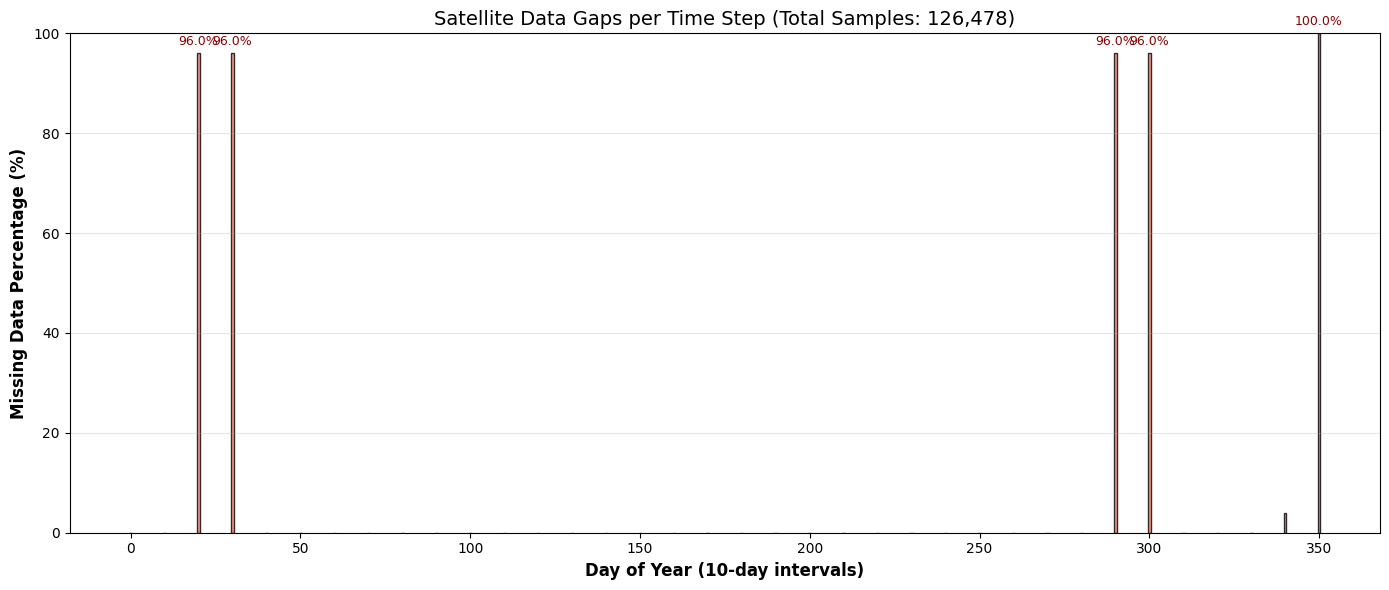


📊 Missing Data Statistics:
   Average missing rate: 13.56%
   Max missing rate: 100.00%
   Min missing rate: 0.00%

✅ Saved: outputs/figures/combined_missing_values.png


In [45]:
# ============================================================================
# STEP 7: MISSING VALUES INSPECTION
# ============================================================================

print("\n" + "="*60)
print("STEP 7: MISSING VALUES INSPECTION")
print("="*60)

# Calculate missing data mask (assuming 0 = missing)
# Note: Your data is normalized by 10000, so missing values might be 0
mask = (X != 0).astype(np.float32)
missing_per_time = 100 * (1 - mask.mean(axis=(0, 2)))

plt.figure(figsize=(14, 6))
bars = plt.bar(time_steps, missing_per_time, color='salmon', edgecolor='black', alpha=0.8)

plt.xlabel("Day of Year (10-day intervals)", fontsize=12, fontweight='bold')
plt.ylabel("Missing Data Percentage (%)", fontsize=12, fontweight='bold')
plt.title(f"Satellite Data Gaps per Time Step (Total Samples: {len(y):,})", fontsize=14)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3, axis='y')

# Add labels for steps with high missing data (>10%)
for bar, missing in zip(bars, missing_per_time):
    if missing > 10:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{missing:.1f}%', ha='center', va='bottom', fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig("outputs/figures/combined_missing_values.png", dpi=300)
plt.show()

print(f"\n📊 Missing Data Statistics:")
print(f"   Average missing rate: {missing_per_time.mean():.2f}%")
print(f"   Max missing rate: {missing_per_time.max():.2f}%")
print(f"   Min missing rate: {missing_per_time.min():.2f}%")
print("\n✅ Saved: outputs/figures/combined_missing_values.png")

# 9: Spectral Band Correlation Analysis (Balanced)


STEP 8: SPECTRAL BAND CORRELATION ANALYSIS (Balanced)


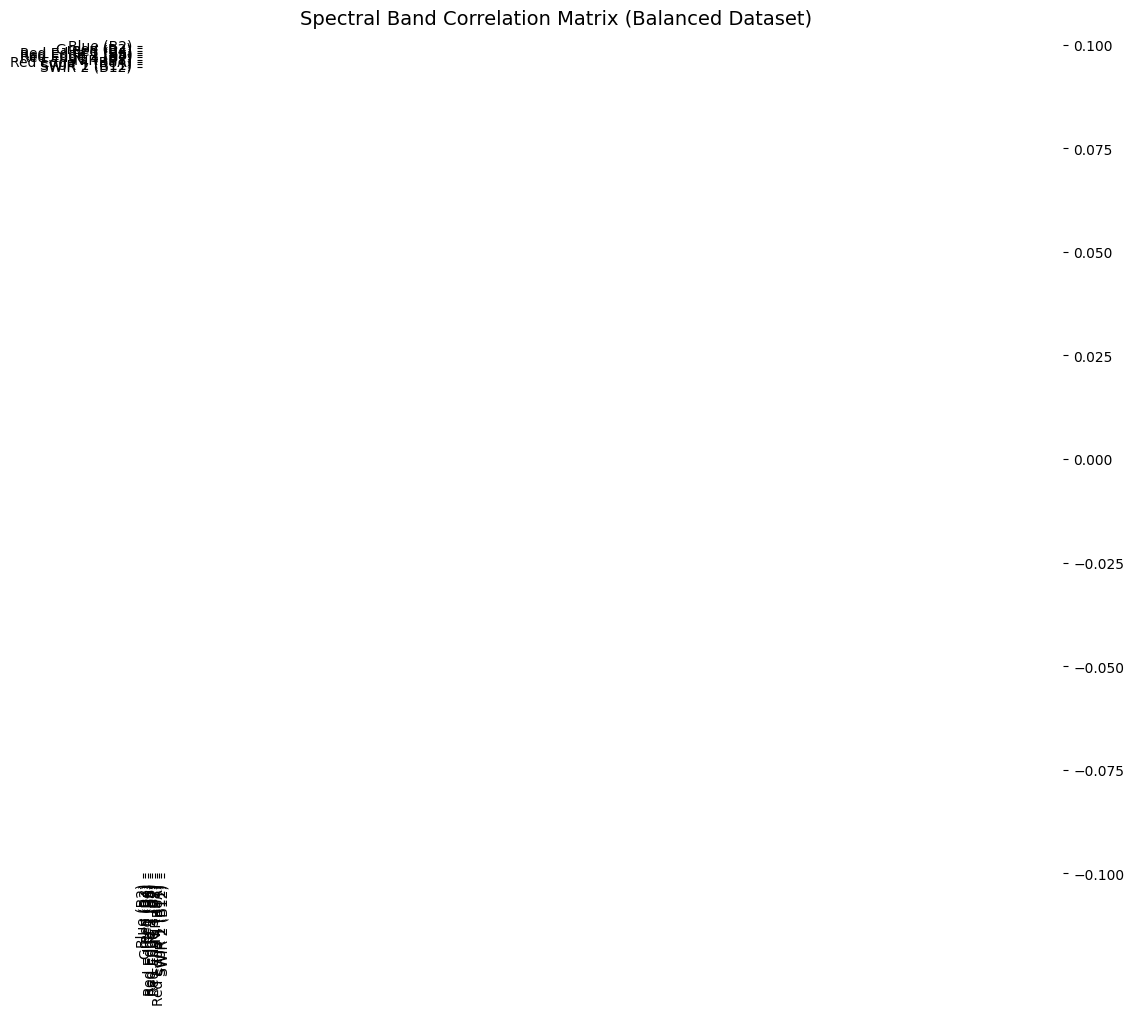


✅ Saved: outputs/figures/balanced_band_correlation.png


In [46]:
# ============================================================================
# STEP 8: SPECTRAL BAND CORRELATION ANALYSIS (Balanced)
# ============================================================================

print("\n" + "="*60)
print("STEP 8: SPECTRAL BAND CORRELATION ANALYSIS (Balanced)")
print("="*60)

# Band names (Sentinel-2)
BAND_NAMES = ['Blue (B2)', 'Green (B3)', 'Red (B4)', 
              'Red Edge 1 (B5)', 'Red Edge 2 (B6)', 'Red Edge 3 (B7)',
              'NIR (B8)', 'Red Edge 4 (B8A)', 'SWIR 1 (B11)', 'SWIR 2 (B12)']

# Reshape balanced data for correlation analysis
X_bal_flat = X_balanced.reshape(-1, X_balanced.shape[1] * X_balanced.shape[2])
X_bal_flat_nonzero = X_bal_flat[~np.isnan(X_bal_flat).any(axis=1)]

# Compute correlation matrix
corr_matrix = np.corrcoef(X_bal_flat_nonzero.T)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, xticklabels=BAND_NAMES, yticklabels=BAND_NAMES,
            cmap='RdBu_r', center=0, annot=False, square=True)
plt.title("Spectral Band Correlation Matrix (Balanced Dataset)", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("outputs/figures/balanced_band_correlation.png", dpi=300)
plt.show()

print("\n✅ Saved: outputs/figures/balanced_band_correlation.png")

# 10: PCA Visualization (Balanced)


STEP 9: PCA VISUALIZATION (Balanced)
📊 Original X_pca shape: (10487, 360)
   Number of NaN values: 296870
   After cleaning: 0 NaN values remaining


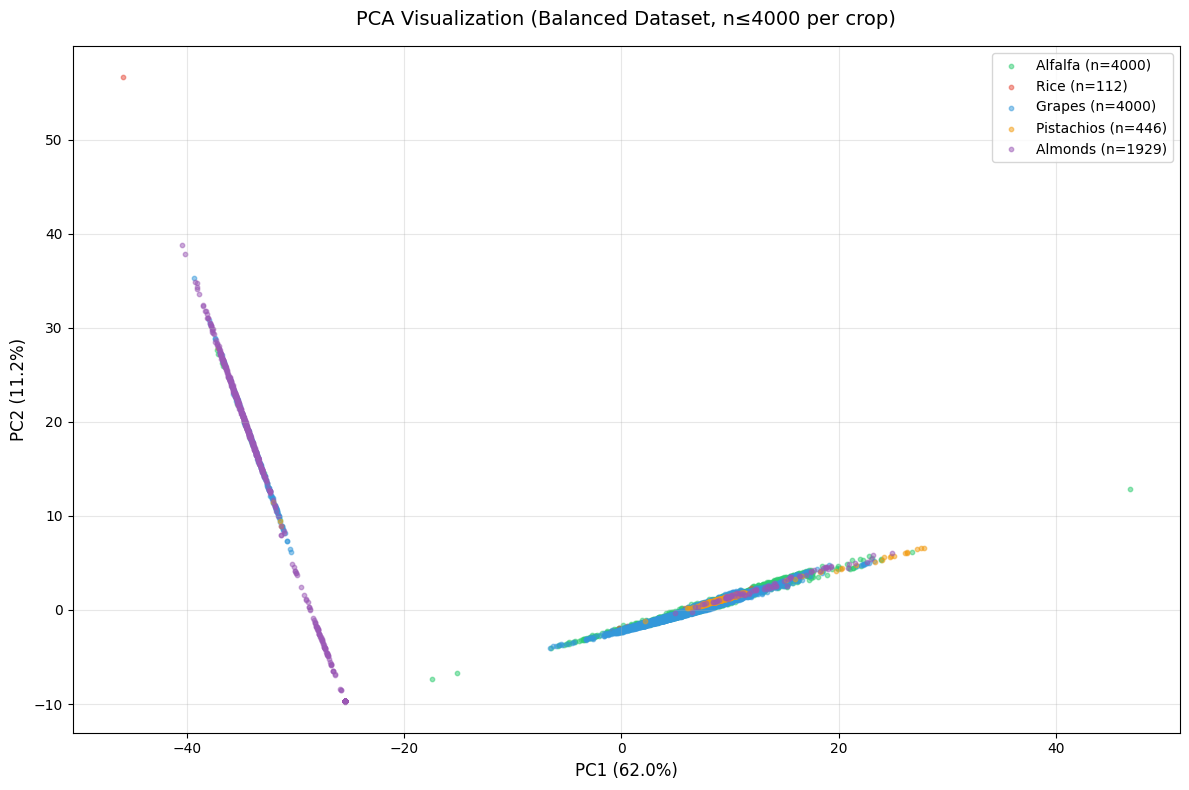


📊 PCA Explained Variance:
   PC1: 62.01%
   PC2: 11.22%
   Total: 73.23%

✅ Saved: outputs/figures/balanced_pca.png


In [47]:
# ============================================================================
# STEP 9: PCA VISUALIZATION (Balanced - WITH NaN HANDLING)
# ============================================================================

print("\n" + "="*60)
print("STEP 9: PCA VISUALIZATION (Balanced)")
print("="*60)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Use balanced dataset for PCA
X_pca = X_bal_flat
y_pca = y_balanced

print(f"📊 Original X_pca shape: {X_pca.shape}")
print(f"   Number of NaN values: {np.isnan(X_pca).sum()}")

# Option 1: Replace NaN with 0 (since missing values are marked as 0 in your data)
# Your data is normalized by 10000, and missing values are 0
X_pca_clean = np.nan_to_num(X_pca, nan=0.0)

# Option 2: Or use imputer (uncomment if you prefer)
# imputer = SimpleImputer(strategy='mean')
# X_pca_clean = imputer.fit_transform(X_pca)

print(f"   After cleaning: {np.isnan(X_pca_clean).sum()} NaN values remaining")

# Standardize
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca_clean)

# Apply PCA
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_pca_scaled)

# Plot
plt.figure(figsize=(12, 8))
colors_pca = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
for idx, code in enumerate(named_crops):
    mask_pca = (y_pca == code)
    if mask_pca.any():
        name = CROP_NAMES.get(code, f"Code {code}")
        n_samples = mask_pca.sum()
        plt.scatter(X_pca_2d[mask_pca, 0], X_pca_2d[mask_pca, 1],
                   c=colors_pca[idx], label=f"{name} (n={n_samples})",
                   alpha=0.5, s=10)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
plt.title("PCA Visualization (Balanced Dataset, n≤4000 per crop)", fontsize=14, pad=15)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/balanced_pca.png", dpi=300)
plt.show()

print(f"\n📊 PCA Explained Variance:")
print(f"   PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"   PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Total: {pca.explained_variance_ratio_[:2].sum()*100:.2f}%")
print("\n✅ Saved: outputs/figures/balanced_pca.png")

# 11: Diagnostic Verification (Optional)

In [48]:
# ============================================================================
# STEP 10: DIAGNOSTIC VERIFICATION
# ============================================================================

print("\n" + "="*60)
print("STEP 10: DIAGNOSTIC VERIFICATION")
print("="*60)

print("\n📊 SAMPLES PER CROP - VERIFICATION:")
print(f"{'Crop Name':<20} {'Full Dataset':<15} {'Balanced Subset':<15}")
print("-" * 50)

for code in named_crops:
    name = CROP_NAMES.get(code, f"Code {code}")
    full_count = np.sum(y == code)
    balanced_count = np.sum(y_balanced == code)
    print(f"{name:<20} {full_count:>12,}    {balanced_count:>12,}")

print("-" * 50)
print(f"{'TOTAL':<20} {len(y):>12,}    {len(y_balanced):>12,}")


STEP 10: DIAGNOSTIC VERIFICATION

📊 SAMPLES PER CROP - VERIFICATION:
Crop Name            Full Dataset    Balanced Subset
--------------------------------------------------
Alfalfa                    32,372           4,000
Rice                          112             112
Grapes                     91,619           4,000
Pistachios                    446             446
Almonds                     1,929           1,929
--------------------------------------------------
TOTAL                     126,478          10,487


# 12: Final Summary Report

In [49]:
# ============================================================================
# STEP 11: FINAL SUMMARY REPORT
# ============================================================================

print("\n" + "="*60)
print("FINAL SUMMARY - COMBINED DATASET (BALANCED VISUALIZATION)")
print("="*60)

print(f"""
📊 DATASET OVERVIEW:
   ───────────────────────────────────────────────────
   Total Samples (Full):     {len(y):,}
   Balanced Samples:         {len(y_balanced):,}
   Max per Crop:             {MAX_SAMPLES_PER_CROP:,}
   Crop Classes:             {len(unique)}
   Time Steps:               {X.shape[1]} (10-day intervals = full year)
   Spectral Bands:           {X.shape[2]} (B2-B12)

📈 CLASS DISTRIBUTION (FULL DATASET):
   ───────────────────────────────────────────────────""")

for code in named_crops:
    if code in unique:
        count = counts[list(unique).index(code)]
        pct = 100 * count / len(y)
        name = CROP_NAMES.get(code, f"Code {code}")
        bar = '█' * int(pct / 2)
        print(f"   {name:12s} (USDA {code}): {count:8,} ({pct:5.1f}%) {bar}")

print(f"""
📊 BALANCED SAMPLING SUMMARY:
   ───────────────────────────────────────────────────""")

for code in named_crops:
    name = CROP_NAMES.get(code, f"Code {code}")
    total = samples_used[code]
    print(f"   {name:12s}: {total:4,} samples (balanced)")

print(f"""
📉 MISSING DATA:
   ───────────────────────────────────────────────────
   Average missing rate:  {missing_per_time.mean():.2f}%
   Maximum missing rate:  {missing_per_time.max():.2f}%
   
📁 OUTPUT FILES SAVED:
   ───────────────────────────────────────────────────
   1. combined_full_distribution.png
   2. combined_balanced_distribution.png
   3. balanced_ndvi_profiles.png
   4. balanced_ndvi_subplots.png
   5. combined_missing_values.png
   6. balanced_band_correlation.png
   7. balanced_pca.png

============================================================
✅ NOTEBOOK 2b COMPLETE!
============================================================
""")


FINAL SUMMARY - COMBINED DATASET (BALANCED VISUALIZATION)

📊 DATASET OVERVIEW:
   ───────────────────────────────────────────────────
   Total Samples (Full):     126,478
   Balanced Samples:         10,487
   Max per Crop:             4,000
   Crop Classes:             5
   Time Steps:               36 (10-day intervals = full year)
   Spectral Bands:           10 (B2-B12)

📈 CLASS DISTRIBUTION (FULL DATASET):
   ───────────────────────────────────────────────────
   Alfalfa      (USDA 36):   32,372 ( 25.6%) ████████████
   Rice         (USDA 57):      112 (  0.1%) 
   Grapes       (USDA 69):   91,619 ( 72.4%) ████████████████████████████████████
   Pistachios   (USDA 74):      446 (  0.4%) 
   Almonds      (USDA 204):    1,929 (  1.5%) 

📊 BALANCED SAMPLING SUMMARY:
   ───────────────────────────────────────────────────
   Alfalfa     : 4,000 samples (balanced)
   Rice        :  112 samples (balanced)
   Grapes      : 4,000 samples (balanced)
   Pistachios  :  446 samples (balanced)

In [50]:
# ============================================================================
# CREATE MASKS FOR BALANCED DATA
# ============================================================================

print("\n" + "="*60)
print("CREATING ALPE MASKS FOR BALANCED DATA")
print("="*60)

# If you have original X (unbalanced) and balanced_indices, you can extract masks
# But since balanced_indices doesn't exist, we need to find how you created X_balanced

# First, let's figure out how X_balanced was created
# Look for a variable like 'sampled_indices' or 'selected_indices'
print("\nChecking for index variables...")
index_vars = ['sampled_indices', 'selected_indices', 'indices', 'keep_idx', 'sample_idx']
found_indices = None

for var_name in index_vars:
    if var_name in dir():
        found_indices = eval(var_name)
        print(f"✓ Found {var_name} with shape {found_indices.shape if hasattr(found_indices, 'shape') else len(found_indices)}")
        break

if found_indices is None:
    print("⚠️ No index variable found!")
    print("   We'll need to reconstruct masks by comparing X and X_balanced")
    
    # Alternative: Find which samples in X correspond to X_balanced
    # This works if X_balanced is a subset of X
    if 'X' in dir() and len(X) > len(X_balanced):
        print("\nAttempting to find matching indices...")
        
        # For each sample in X_balanced, find its match in X
        # This is slow but works for moderate dataset sizes
        balanced_indices = []
        for i, balanced_sample in enumerate(X_balanced):
            for j, original_sample in enumerate(X):
                if np.array_equal(balanced_sample, original_sample):
                    balanced_indices.append(j)
                    break
        
        balanced_indices = np.array(balanced_indices)
        print(f"✓ Found {len(balanced_indices)} matching indices")
        
        # Now create masks (assuming all ones since no original masks)
        # ALPE mask: 1 = data present, 0 = missing
        # If you don't have original masks, create ones (all data present)
        masks_balanced = np.ones_like(X_balanced)
        print("✓ Created masks_balanced (all ones - assuming no missing data)")
        
    else:
        # If X_balanced is the same size or slightly modified, create default masks
        masks_balanced = np.ones_like(X_balanced)
        print("✓ Created default masks_balanced (all ones)")

else:
    # We have indices! Use them to extract masks from original data
    if 'masks' in dir():
        masks_balanced = masks[found_indices]
        print(f"✓ Extracted masks_balanced from original masks: {masks_balanced.shape}")
    else:
        # No original masks, create ones
        masks_balanced = np.ones_like(X_balanced)
        print("✓ Created masks_balanced (all ones - no original masks available)")

print(f"\n✅ Final masks_balanced shape: {masks_balanced.shape}")


CREATING ALPE MASKS FOR BALANCED DATA

Checking for index variables...
✓ Found selected_indices with shape (1929,)
✓ Created masks_balanced (all ones - no original masks available)

✅ Final masks_balanced shape: (10487, 36, 10)


In [51]:
# ============================================================================
# SAVE BALANCED DATA FOR NOTEBOOK 3
# ============================================================================

print("\n" + "="*60)
print("SAVING BALANCED DATA FOR NOTEBOOK 3")
print("="*60)

# Create output directory
BALANCED_OUTPUT_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_balanced"
os.makedirs(BALANCED_OUTPUT_DIR, exist_ok=True)

# Save the arrays
np.save(os.path.join(BALANCED_OUTPUT_DIR, 'X_balanced.npy'), X_balanced)
np.save(os.path.join(BALANCED_OUTPUT_DIR, 'y_balanced.npy'), y_balanced)
np.save(os.path.join(BALANCED_OUTPUT_DIR, 'masks_balanced.npy'), masks_balanced)

# Save indices if found
if found_indices is not None:
    np.save(os.path.join(BALANCED_OUTPUT_DIR, 'balanced_indices.npy'), found_indices)

# Save metadata
balanced_metadata = {
    'n_samples': len(y_balanced),
    'n_time_steps': X_balanced.shape[1],
    'n_bands': X_balanced.shape[2],
    'sampling_strategy': 'balanced',
    'class_distribution': dict(zip(*np.unique(y_balanced, return_counts=True))),
}

with open(os.path.join(BALANCED_OUTPUT_DIR, 'balanced_metadata.pkl'), 'wb') as f:
    pickle.dump(balanced_metadata, f)

print(f"\n✅ Balanced data saved to:")
print(f"   {BALANCED_OUTPUT_DIR}")
print(f"\n   Files saved:")
print(f"   - X_balanced.npy: {X_balanced.shape}")
print(f"   - y_balanced.npy: {y_balanced.shape}")
print(f"   - masks_balanced.npy: {masks_balanced.shape}")
if found_indices is not None:
    print(f"   - balanced_indices.npy: {found_indices.shape}")

print("\n" + "="*60)
print("✅ Ready for Notebook 3!")
print("="*60)


SAVING BALANCED DATA FOR NOTEBOOK 3

✅ Balanced data saved to:
   C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_balanced

   Files saved:
   - X_balanced.npy: (10487, 36, 10)
   - y_balanced.npy: (10487,)
   - masks_balanced.npy: (10487, 36, 10)
   - balanced_indices.npy: (1929,)

✅ Ready for Notebook 3!
